# Exploratory Data Analysis: Criteo Uplift Dataset

## Giới thiệu dữ liệu

Criteo Uplift Dataset là dữ liệu user-level được xây dựng từ các thí nghiệm đo lường tác động tăng thêm của quảng cáo trực tuyến. Mục tiêu chính của dữ liệu là phục vụ bài toán **uplift modeling**, tức ước lượng mức thay đổi của hành vi người dùng khi có tác động quảng cáo so với khi không có tác động quảng cáo.

Mỗi dòng dữ liệu đại diện cho một người dùng trong bối cảnh thử nghiệm quảng cáo. Dataset gồm ba nhóm cột chính:

- **Feature ẩn danh**: các cột dạng `f0`, `f1`, ..., thường là biến số đã được ẩn danh hoặc biến đổi để bảo vệ thông tin gốc. Không có mô tả business cụ thể cho từng feature.
- **Biến can thiệp / hiển thị**: `treatment` cho biết người dùng thuộc nhóm treatment hay control; `exposure` cho biết người dùng có thực sự được hiển thị quảng cáo hay không.
- **Biến kết quả**: `visit` cho biết người dùng có truy cập website hay không; `conversion` cho biết người dùng có thực hiện hành động chuyển đổi hay không.

Do các feature đã được ẩn danh, notebook không diễn giải ý nghĩa business của từng feature. Phần khám phá dữ liệu tập trung vào chất lượng dữ liệu, thống kê mô tả cơ bản của feature, cấu trúc treatment/control, phân bố outcome và uplift tổng quan giữa nhóm treatment và control.

## Mục tiêu phân tích

1. Kiểm tra cấu trúc dữ liệu, số dòng, số cột và kiểu dữ liệu.
2. Xác định vai trò của từng nhóm cột trong dataset.
3. Kiểm tra chất lượng dữ liệu: missing values, infinite values, duplicates và các cột ít biến thiên.
4. Thống kê mô tả cơ bản cho các feature ẩn danh, chỉ bao gồm count, mean, std, min, max và quantiles.
5. Phân tích `treatment`, `exposure`, `visit`, `conversion`.
6. Tính baseline uplift cho `visit` và `conversion`.
7. Tổng hợp kết luận dựa trên các bảng và biểu đồ được tạo trong notebook.

## 0. Cài đặt và import thư viện

Cell này thiết lập các thư viện cần thiết cho quá trình EDA. Notebook ưu tiên sử dụng `pandas`, `numpy` và `matplotlib` để đảm bảo dễ chạy trong nhiều môi trường khác nhau.

In [1]:
import os
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment is ready.")

Environment is ready.


## 1. Load dữ liệu

Notebook hỗ trợ hai cách load dữ liệu:

1. **Local data**: đọc file `../data/raw/criteo-uplift.csv`. File này được tải tự động khi thực hiện chương trình `download_criteo.py` trong project.
2. **Non-local data**: đọc trực tiếp từ nguồn remote, phù hợp khi chưa có file local hoặc cần chạy notebook độc lập.

In [2]:
# ======================
# CẤU HÌNH LOAD DỮ LIỆU
# ======================

DATA_SOURCE = "local"  # "local" hoặc "remote"

# Cách 1: đọc dữ liệu local.
# File này được tải tự động khi thực hiện chương trình download_criteo.py.
LOCAL_CSV_PATH = Path("../data/raw/criteo-uplift.csv")

# Cách 2: đọc dữ liệu không local từ nguồn remote.
REMOTE_CSV_URL = "https://huggingface.co/datasets/criteo/criteo-uplift/resolve/main/criteo-research-uplift-v2.1.csv.gz"

# Đặt None để đọc toàn bộ dữ liệu. Đặt số nguyên để đọc một phần dữ liệu khi cần chạy nhanh.
# Ví dụ: NROWS = 500_000
NROWS = None


def load_criteo_data(data_source: str = "local", nrows=None) -> pd.DataFrame:
    """Load Criteo Uplift Dataset từ local path hoặc remote URL."""
    data_source = data_source.lower().strip()

    if data_source == "local":
        if not LOCAL_CSV_PATH.exists():
            raise FileNotFoundError(
                f"Không tìm thấy file local: {LOCAL_CSV_PATH}. "
                "Cần chạy download_criteo.py để tải dữ liệu tự động, "
                "hoặc đổi DATA_SOURCE = 'remote'."
            )
        print(f"Loading local data from: {LOCAL_CSV_PATH}")
        return pd.read_csv(LOCAL_CSV_PATH, nrows=nrows)

    if data_source == "remote":
        print(f"Loading remote data from: {REMOTE_CSV_URL}")
        return pd.read_csv(REMOTE_CSV_URL, compression="gzip", nrows=nrows)

    raise ValueError("DATA_SOURCE chỉ nhận giá trị 'local' hoặc 'remote'.")


df = load_criteo_data(DATA_SOURCE, nrows=NROWS)
print("Data loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Loading local data from: ..\data\raw\criteo-uplift.csv
Data loaded successfully.
Shape: (13979592, 16)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616365,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616365,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616365,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616365,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


## 2. Kiểm tra tổng quan và tối ưu kiểu dữ liệu

Phần này kiểm tra kích thước dữ liệu, danh sách cột, kiểu dữ liệu, số lượng giá trị phân biệt và dung lượng bộ nhớ. Sau đó các cột số được downcast để giảm mức sử dụng RAM khi xử lý dataset lớn.

In [3]:
def memory_usage_mb(dataframe: pd.DataFrame) -> float:
    """Tính dung lượng bộ nhớ của dataframe theo MB."""
    return dataframe.memory_usage(deep=True).sum() / 1024**2


print("Shape:", df.shape)
print(f"Memory before optimization: {memory_usage_mb(df):,.2f} MB")

column_overview = pd.DataFrame({
    "column": df.columns,
    "dtype": [df[c].dtype for c in df.columns],
    "n_unique": [df[c].nunique(dropna=False) for c in df.columns],
    "missing": [df[c].isna().sum() for c in df.columns],
    "missing_rate": [df[c].isna().mean() for c in df.columns],
})

display(column_overview)


def optimize_numeric_dtypes(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Downcast các cột số để tiết kiệm RAM."""
    out = dataframe.copy()
    for col in out.columns:
        if pd.api.types.is_integer_dtype(out[col]):
            out[col] = pd.to_numeric(out[col], downcast="integer")
        elif pd.api.types.is_float_dtype(out[col]):
            out[col] = pd.to_numeric(out[col], downcast="float")
    return out


df = optimize_numeric_dtypes(df)
print(f"Memory after optimization: {memory_usage_mb(df):,.2f} MB")

dtypes_after_optimization = df.dtypes.to_frame("dtype")
display(dtypes_after_optimization)

Shape: (13979592, 16)
Memory before optimization: 1,706.49 MB


,column,dtype,n_unique,missing,missing_rate
0,f0,float64,2181959,0,0.000000
1,f1,float64,60,0,0.000000
2,f2,float64,2051900,0,0.000000
3,f3,float64,552,0,0.000000
4,f4,float64,260,0,0.000000
5,f5,float64,132,0,0.000000
6,f6,float64,1645,0,0.000000
7,f7,float64,622143,0,0.000000
8,f8,float64,3743,0,0.000000
9,f9,float64,1594,0,0.000000


Memory after optimization: 693.26 MB


,dtype
f0,float32
f1,float32
f2,float32
f3,float32
f4,float32
f5,float32
f6,float32
f7,float32
f8,float32
f9,float32


## 3. Xác định vai trò của từng nhóm cột

Dataset được chia thành ba nhóm chính:

- `feature_cols`: các feature ẩn danh dạng `f0`, `f1`, ...
- `treatment_cols`: các biến liên quan đến can thiệp hoặc hiển thị quảng cáo, gồm `treatment` và `exposure` nếu tồn tại.
- `outcome_cols`: các biến kết quả, gồm `visit` và `conversion` nếu tồn tại.

Việc tách rõ vai trò cột giúp tránh nhầm lẫn giữa feature đầu vào, biến can thiệp và biến kết quả khi phân tích uplift.

In [4]:
def sort_feature_cols(cols):
    """Sort các cột f0, f1, ..., fN theo thứ tự số."""
    def key_fn(col):
        try:
            return int(col[1:])
        except Exception:
            return 10**9
    return sorted(cols, key=key_fn)


feature_cols = sort_feature_cols([c for c in df.columns if c.startswith("f") and c[1:].isdigit()])
treatment_cols = [c for c in ["treatment", "exposure"] if c in df.columns]
outcome_cols = [c for c in ["visit", "conversion"] if c in df.columns]
other_cols = [c for c in df.columns if c not in feature_cols + treatment_cols + outcome_cols]

column_roles = pd.DataFrame({
    "column": feature_cols + treatment_cols + outcome_cols + other_cols,
    "role": (
        ["anonymized_feature"] * len(feature_cols)
        + ["treatment_related"] * len(treatment_cols)
        + ["outcome"] * len(outcome_cols)
        + ["other"] * len(other_cols)
    ),
})

display(column_roles)

print("Feature columns:", feature_cols)
print("Treatment-related columns:", treatment_cols)
print("Outcome columns:", outcome_cols)
print("Other columns:", other_cols)

,column,role
0,f0,anonymized_feature
1,f1,anonymized_feature
2,f2,anonymized_feature
3,f3,anonymized_feature
4,f4,anonymized_feature
5,f5,anonymized_feature
6,f6,anonymized_feature
7,f7,anonymized_feature
8,f8,anonymized_feature
9,f9,anonymized_feature


Feature columns: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']
Treatment-related columns: ['treatment', 'exposure']
Outcome columns: ['visit', 'conversion']
Other columns: []


## 4. Data quality checks

Phần này kiểm tra các vấn đề chất lượng dữ liệu thường gặp:

- Missing values theo từng cột.
- Infinite values trong các cột số.
- Duplicate rows.
- Constant hoặc near-constant columns.

Các kiểm tra này không phụ thuộc vào ý nghĩa business của feature nên vẫn phù hợp với dữ liệu đã ẩn danh.

In [5]:
# Missing values
missing_summary = pd.DataFrame({
    "column": df.columns,
    "missing_count": [df[c].isna().sum() for c in df.columns],
    "missing_rate": [df[c].isna().mean() for c in df.columns],
}).sort_values("missing_rate", ascending=False)

display(missing_summary)

# Infinite values trong các cột số
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
inf_summary = pd.DataFrame({
    "column": numeric_cols,
    "positive_inf": [np.isposinf(df[c].to_numpy()).sum() for c in numeric_cols],
    "negative_inf": [np.isneginf(df[c].to_numpy()).sum() for c in numeric_cols],
})
inf_summary["total_inf"] = inf_summary["positive_inf"] + inf_summary["negative_inf"]
inf_summary = inf_summary.sort_values("total_inf", ascending=False)

display(inf_summary)

# Duplicate rows
CHECK_DUPLICATES_FULL = True
if CHECK_DUPLICATES_FULL:
    duplicate_count = df.duplicated().sum()
    print(f"Duplicate rows: {duplicate_count:,}")
else:
    sample_for_duplicates = df.sample(min(len(df), 500_000), random_state=RANDOM_STATE)
    duplicate_count = sample_for_duplicates.duplicated().sum()
    print(f"Duplicate rows in sample: {duplicate_count:,}")

# Constant và near-constant columns
constant_cols = []
near_constant_cols = []
near_constant_threshold = 0.999

for col in df.columns:
    vc = df[col].value_counts(dropna=False, normalize=True)
    if len(vc) <= 1:
        constant_cols.append(col)
    elif vc.iloc[0] >= near_constant_threshold:
        near_constant_cols.append(col)

print("Constant columns:", constant_cols)
print(f"Near-constant columns with top value rate >= {near_constant_threshold}:", near_constant_cols)

,column,missing_count,missing_rate
0,f0,0,0.000000
1,f1,0,0.000000
2,f2,0,0.000000
3,f3,0,0.000000
4,f4,0,0.000000
5,f5,0,0.000000
6,f6,0,0.000000
7,f7,0,0.000000
8,f8,0,0.000000
9,f9,0,0.000000


,column,positive_inf,negative_inf,total_inf
0,f0,0,0,0
1,f1,0,0,0
2,f2,0,0,0
3,f3,0,0,0
4,f4,0,0,0
5,f5,0,0,0
6,f6,0,0,0
7,f7,0,0,0
8,f8,0,0,0
9,f9,0,0,0


Duplicate rows: 1,655,747
Constant columns: []
Near-constant columns with top value rate >= 0.999: []


## 5. Thống kê mô tả cơ bản cho feature ẩn danh

Các cột `f0`, `f1`, ... là feature đã được ẩn danh nên không diễn giải ý nghĩa business. Phần này chỉ giữ thống kê mô tả cơ bản như count, mean, std, min, max và một số quantiles để hiểu range và scale của từng feature.

In [6]:
if feature_cols:
    feature_summary = df[feature_cols].describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    ).T
    feature_summary["missing_count"] = df[feature_cols].isna().sum()
    feature_summary["missing_rate"] = df[feature_cols].isna().mean()
    feature_summary["n_unique"] = df[feature_cols].nunique(dropna=False)
    feature_summary = feature_summary[[
        "count", "missing_count", "missing_rate", "n_unique",
        "mean", "std", "min", "1%", "5%", "25%", "50%", "75%", "95%", "99%", "max"
    ]]
else:
    feature_summary = pd.DataFrame()

print("Number of anonymized feature columns:", len(feature_cols))
display(feature_summary)

Number of anonymized feature columns: 12


,count,missing_count,missing_rate,n_unique,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
f0,"13,979,592.000000",0,0.000000,2181959,19.620296,5.377464,12.616364,12.616364,12.616364,12.616364,21.923413,24.436459,26.311867,26.672877,26.745255
f1,"13,979,592.000000",0,0.000000,60,10.069978,0.104756,10.059654,10.059654,10.059654,10.059654,10.059654,10.059654,10.059654,10.679513,16.344187
f2,"13,979,592.000000",0,0.000000,808663,8.446583,0.299316,8.214383,8.214383,8.214383,8.214383,8.214383,8.723335,9.004230,9.042916,9.051962
f3,"13,979,592.000000",0,0.000000,552,4.178923,1.336645,-8.398387,-1.733228,0.973841,4.679882,4.679882,4.679882,4.679882,4.679882,4.679882
f4,"13,979,592.000000",0,0.000000,260,10.338838,0.343308,10.280525,10.280525,10.280525,10.280525,10.280525,10.280525,10.280525,11.973288,21.123508
f5,"13,979,592.000000",0,0.000000,132,4.028512,0.431097,-9.011891,2.230907,3.013064,4.115453,4.115453,4.115453,4.115453,4.115453,4.115453
f6,"13,979,592.000000",0,0.000000,1645,-4.155355,4.577914,-31.429783,-17.777273,-13.353455,-6.699321,-2.411115,0.294443,0.294443,0.294443,0.294443
f7,"13,979,592.000000",0,0.000000,622143,5.101766,1.205248,4.833815,4.833815,4.833815,4.833815,4.833815,4.833815,6.045297,11.482084,11.998401
f8,"13,979,592.000000",0,0.000000,3743,3.933581,0.056660,3.635107,3.751603,3.806309,3.910792,3.971858,3.971858,3.971858,3.971858,3.971858
f9,"13,979,592.000000",0,0.000000,1594,16.027639,7.018975,13.190056,13.190056,13.190056,13.190056,13.190056,13.190056,33.712555,44.893639,75.295021


## 6. Tổng quan `treatment`, `exposure` và outcome

Phần này tập trung vào các biến có ý nghĩa phân tích rõ ràng:

- `treatment`: nhóm treatment/control.
- `exposure`: trạng thái thực sự được hiển thị quảng cáo.
- `visit`: trạng thái có truy cập website.
- `conversion`: trạng thái có chuyển đổi.

Các biến này được tóm tắt bằng số lượng và tỷ lệ từng giá trị.

,column,value,count,rate
0,treatment,0,2096937,0.150000
1,treatment,1,11882655,0.850000
2,exposure,0,13551380,0.969369
3,exposure,1,428212,0.030631
4,visit,0,13322663,0.953008
5,visit,1,656929,0.046992
6,conversion,0,13938818,0.997083
7,conversion,1,40774,0.002917


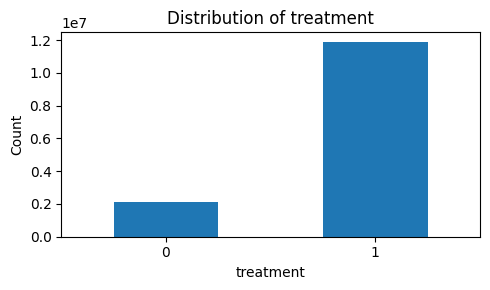

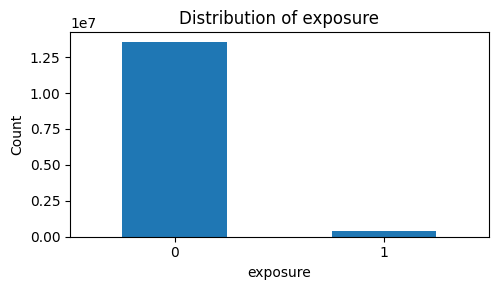

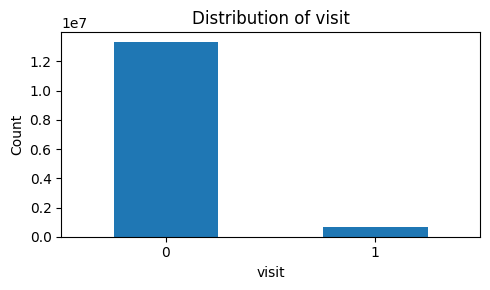

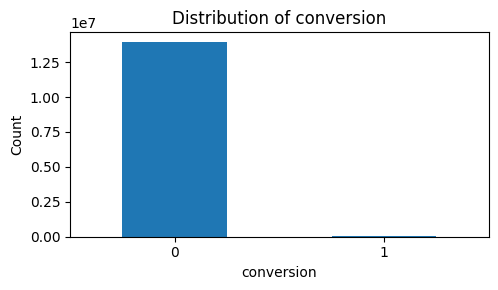

exposure,0,1,All
treatment,,,
0,2096937,0,2096937
1,11454443,428212,11882655
All,13551380,428212,13979592


exposure,0,1
treatment,,
0,1.000000,0.000000
1,0.963963,0.036037


In [7]:
def binary_column_summary(dataframe: pd.DataFrame, cols) -> pd.DataFrame:
    """Tạo bảng count/rate cho các cột binary hoặc categorical ít giá trị."""
    summaries = []
    n = len(dataframe)
    for col in cols:
        value_counts = dataframe[col].value_counts(dropna=False).sort_index()
        for value, count in value_counts.items():
            summaries.append({
                "column": col,
                "value": value,
                "count": int(count),
                "rate": count / n if n else np.nan,
            })
    return pd.DataFrame(summaries)


binary_cols = [c for c in ["treatment", "exposure", "visit", "conversion"] if c in df.columns]
binary_summary = binary_column_summary(df, binary_cols)
display(binary_summary)

# Bar chart cho count của từng biến chính
for col in binary_cols:
    counts = df[col].value_counts(dropna=False).sort_index()
    ax = counts.plot(kind="bar", figsize=(5, 3), title=f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Crosstab treatment x exposure nếu có đủ hai cột
if {"treatment", "exposure"}.issubset(df.columns):
    treatment_exposure_crosstab = pd.crosstab(
        df["treatment"],
        df["exposure"],
        margins=True,
        dropna=False
    )
    display(treatment_exposure_crosstab)

    treatment_exposure_rate = pd.crosstab(
        df["treatment"],
        df["exposure"],
        normalize="index",
        dropna=False
    )
    display(treatment_exposure_rate)
else:
    treatment_exposure_crosstab = pd.DataFrame()
    treatment_exposure_rate = pd.DataFrame()

## 7. Outcome rate và class imbalance

`visit` và `conversion` là các biến outcome nhị phân. Với dữ liệu quảng cáo, `conversion` thường là sự kiện hiếm, do đó cần đánh giá tỷ lệ positive class trước khi xây dựng mô hình.

,outcome,total_rows,positive_count,negative_count,positive_rate
0,visit,13979592,656929,13322663,0.046992
1,conversion,13979592,40774,13938818,0.002917


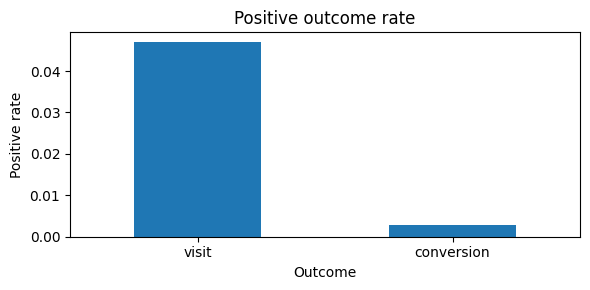

In [8]:
def outcome_rate_summary(dataframe: pd.DataFrame, outcomes) -> pd.DataFrame:
    """Tính count và positive rate cho từng outcome."""
    rows = []
    n = len(dataframe)
    for outcome in outcomes:
        positive_count = dataframe[outcome].sum()
        rows.append({
            "outcome": outcome,
            "total_rows": n,
            "positive_count": int(positive_count),
            "negative_count": int(n - positive_count),
            "positive_rate": positive_count / n if n else np.nan,
        })
    return pd.DataFrame(rows)


outcome_summary = outcome_rate_summary(df, outcome_cols)
display(outcome_summary)

if not outcome_summary.empty:
    ax = outcome_summary.set_index("outcome")["positive_rate"].plot(
        kind="bar",
        figsize=(6, 3),
        title="Positive outcome rate"
    )
    ax.set_xlabel("Outcome")
    ax.set_ylabel("Positive rate")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 8. Outcome theo treatment/control

Phần này so sánh `visit` và `conversion` giữa nhóm treatment và control. Đây là bước nền tảng trước khi tính baseline uplift.

,treatment_value,outcome,n,positive_count,positive_rate
0,0,visit,2096937,80105,0.038201
1,0,conversion,2096937,4063,0.001938
2,1,visit,11882655,576824,0.048543
3,1,conversion,11882655,36711,0.003089


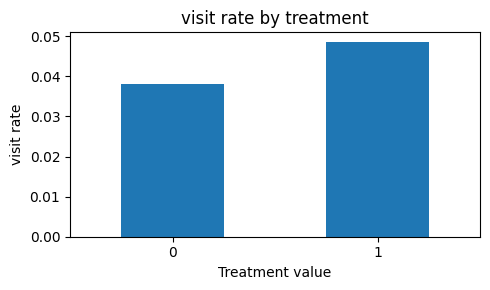

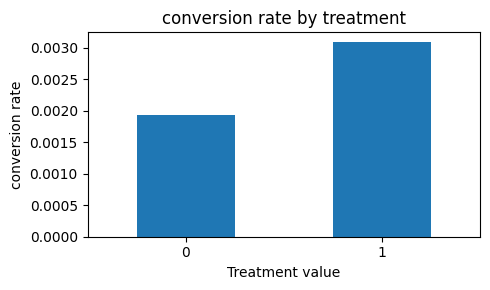

In [9]:
def outcome_by_treatment_summary(
    dataframe: pd.DataFrame,
    treatment_col: str = "treatment",
    outcomes=None,
) -> pd.DataFrame:
    """Tính outcome rate theo treatment/control."""
    if outcomes is None:
        outcomes = []
    if treatment_col not in dataframe.columns:
        return pd.DataFrame()

    rows = []
    for treatment_value, group in dataframe.groupby(treatment_col, dropna=False):
        for outcome in outcomes:
            rows.append({
                "treatment_value": treatment_value,
                "outcome": outcome,
                "n": len(group),
                "positive_count": int(group[outcome].sum()),
                "positive_rate": group[outcome].mean(),
            })
    return pd.DataFrame(rows)


outcome_by_treatment = outcome_by_treatment_summary(df, "treatment", outcome_cols)
display(outcome_by_treatment)

if not outcome_by_treatment.empty:
    for outcome in outcome_cols:
        plot_data = outcome_by_treatment[outcome_by_treatment["outcome"] == outcome].copy()
        plot_data["treatment_value"] = plot_data["treatment_value"].astype(str)
        ax = plot_data.set_index("treatment_value")["positive_rate"].plot(
            kind="bar",
            figsize=(5, 3),
            title=f"{outcome} rate by treatment"
        )
        ax.set_xlabel("Treatment value")
        ax.set_ylabel(f"{outcome} rate")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

## 9. Baseline uplift

Baseline uplift được tính bằng chênh lệch outcome rate giữa nhóm treatment và nhóm control:
$$
\text{baseline uplift} = P(Y=1 \mid T=1) - P(Y=1 \mid T=0)
$$
Chỉ số này là phép so sánh tổng quan, chưa thay thế cho mô hình uplift ở cấp độ từng user. Tuy nhiên, nó cung cấp baseline quan trọng về hướng và độ lớn của tác động trung bình trong dữ liệu.

,outcome,n_control,n_treatment,control_rate,treatment_rate,baseline_uplift_abs,baseline_uplift_relative
0,visit,2096937,11882655,0.038201,0.048543,0.010342,0.270737
1,conversion,2096937,11882655,0.001938,0.003089,0.001152,0.594488


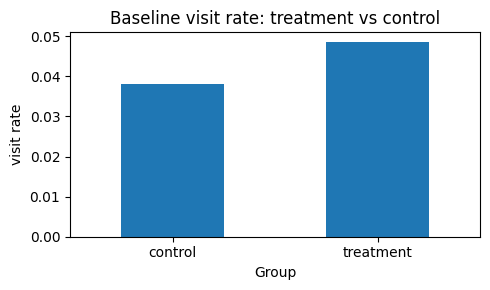

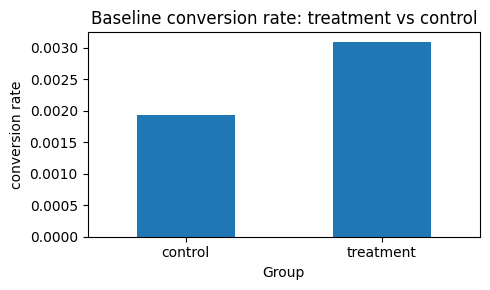

In [10]:
def compute_baseline_uplift(
    dataframe: pd.DataFrame,
    treatment_col: str = "treatment",
    outcomes=None,
) -> pd.DataFrame:
    """Tính baseline uplift cho từng outcome."""
    if outcomes is None:
        outcomes = []
    if treatment_col not in dataframe.columns:
        return pd.DataFrame()

    treatment_values = set(dataframe[treatment_col].dropna().unique())
    required_values = {0, 1}
    if not required_values.issubset(treatment_values):
        print(f"Cột {treatment_col} không có đủ hai giá trị 0 và 1.")
        return pd.DataFrame()

    rows = []
    control = dataframe[dataframe[treatment_col] == 0]
    treated = dataframe[dataframe[treatment_col] == 1]

    for outcome in outcomes:
        control_rate = control[outcome].mean()
        treatment_rate = treated[outcome].mean()
        rows.append({
            "outcome": outcome,
            "n_control": len(control),
            "n_treatment": len(treated),
            "control_rate": control_rate,
            "treatment_rate": treatment_rate,
            "baseline_uplift_abs": treatment_rate - control_rate,
            "baseline_uplift_relative": (
                (treatment_rate - control_rate) / control_rate
                if pd.notna(control_rate) and control_rate != 0
                else np.nan
            ),
        })
    return pd.DataFrame(rows)


baseline_uplift = compute_baseline_uplift(df, "treatment", outcome_cols)
display(baseline_uplift)

if not baseline_uplift.empty:
    for _, row in baseline_uplift.iterrows():
        outcome = row["outcome"]
        plot_df = pd.DataFrame({
            "group": ["control", "treatment"],
            "rate": [row["control_rate"], row["treatment_rate"]],
        })
        ax = plot_df.set_index("group")["rate"].plot(
            kind="bar",
            figsize=(5, 3),
            title=f"Baseline {outcome} rate: treatment vs control"
        )
        ax.set_xlabel("Group")
        ax.set_ylabel(f"{outcome} rate")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

## 10. Phân tích `exposure`

`exposure` thể hiện việc người dùng có thực sự được hiển thị quảng cáo hay không. Biến này cần được phân tích riêng vì nó không hoàn toàn tương đương với `treatment`. Trong các phân tích causal cơ bản, `treatment` thường gần với assignment hơn, còn `exposure` là trạng thái sau assignment.

,column,value,count,rate
0,exposure,0,13551380,0.969369
1,exposure,1,428212,0.030631


exposure,0,1,All
treatment,,,
0,2096937,0,2096937
1,11454443,428212,11882655
All,13551380,428212,13979592


exposure,0,1
treatment,,
0,1.000000,0.000000
1,0.963963,0.036037


,exposure_value,outcome,n,positive_count,positive_rate
0,0,visit,13551380,479419,0.035378
1,0,conversion,13551380,17743,0.001309
2,1,visit,428212,177510,0.414538
3,1,conversion,428212,23031,0.053784


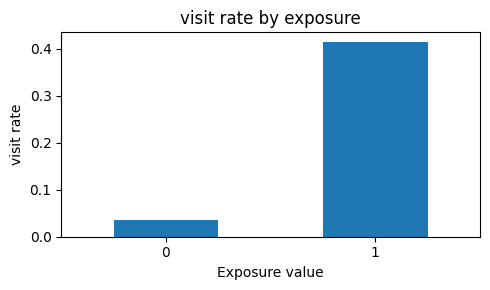

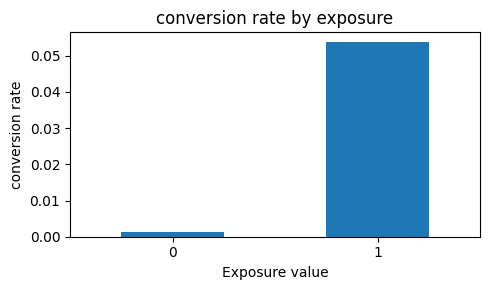

In [11]:
if "exposure" in df.columns:
    exposure_summary = binary_column_summary(df, ["exposure"])
    display(exposure_summary)

    if "treatment" in df.columns:
        exposure_by_treatment = pd.crosstab(
            df["treatment"],
            df["exposure"],
            margins=True,
            dropna=False
        )
        exposure_by_treatment_rate = pd.crosstab(
            df["treatment"],
            df["exposure"],
            normalize="index",
            dropna=False
        )
        display(exposure_by_treatment)
        display(exposure_by_treatment_rate)

    exposure_outcome_summary = outcome_by_treatment_summary(
        df,
        treatment_col="exposure",
        outcomes=outcome_cols,
    )
    exposure_outcome_summary = exposure_outcome_summary.rename(columns={"treatment_value": "exposure_value"})
    display(exposure_outcome_summary)

    for outcome in outcome_cols:
        plot_data = exposure_outcome_summary[exposure_outcome_summary["outcome"] == outcome].copy()
        if not plot_data.empty:
            plot_data["exposure_value"] = plot_data["exposure_value"].astype(str)
            ax = plot_data.set_index("exposure_value")["positive_rate"].plot(
                kind="bar",
                figsize=(5, 3),
                title=f"{outcome} rate by exposure"
            )
            ax.set_xlabel("Exposure value")
            ax.set_ylabel(f"{outcome} rate")
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()
else:
    exposure_summary = pd.DataFrame()
    exposure_by_treatment = pd.DataFrame()
    exposure_by_treatment_rate = pd.DataFrame()
    exposure_outcome_summary = pd.DataFrame()
    print("Column 'exposure' is not available in this dataset.")

## 11. Kiểm tra tính nhất quán logic

Một số kiểm tra logic giúp phát hiện các điểm bất thường trong dữ liệu:

- Số dòng có `conversion = 1` nhưng `visit = 0`.
- Số dòng có `exposure = 1` trong nhóm `treatment = 0`.
- Số dòng có giá trị ngoài tập `{0, 1}` đối với các biến binary chính.

In [12]:
consistency_checks = []

if {"visit", "conversion"}.issubset(df.columns):
    conversion_without_visit = ((df["conversion"] == 1) & (df["visit"] == 0)).sum()
    consistency_checks.append({
        "check": "conversion = 1 and visit = 0",
        "count": int(conversion_without_visit),
        "rate": conversion_without_visit / len(df) if len(df) else np.nan,
    })

if {"treatment", "exposure"}.issubset(df.columns):
    exposure_in_control = ((df["treatment"] == 0) & (df["exposure"] == 1)).sum()
    consistency_checks.append({
        "check": "treatment = 0 and exposure = 1",
        "count": int(exposure_in_control),
        "rate": exposure_in_control / len(df) if len(df) else np.nan,
    })

for col in binary_cols:
    invalid_count = (~df[col].dropna().isin([0, 1])).sum()
    consistency_checks.append({
        "check": f"{col} has values outside {{0, 1}}",
        "count": int(invalid_count),
        "rate": invalid_count / len(df) if len(df) else np.nan,
    })

consistency_summary = pd.DataFrame(consistency_checks)
display(consistency_summary)

,check,count,rate
0,conversion = 1 and visit = 0,0,0.000000
1,treatment = 0 and exposure = 1,0,0.000000
2,"treatment has values outside {0, 1}",0,0.000000
3,"exposure has values outside {0, 1}",0,0.000000
4,"visit has values outside {0, 1}",0,0.000000
5,"conversion has values outside {0, 1}",0,0.000000


## 12. Tổng hợp kết luận từ kết quả EDA

Cell này tạo phần kết luận tự động dựa trên các bảng và biểu đồ đã được tính trong notebook. Nội dung kết luận sẽ thay đổi theo dữ liệu thực tế được load, bao gồm cả trường hợp chạy sample bằng `NROWS`.

In [13]:
def format_rate(value):
    if pd.isna(value):
        return "N/A"
    return f"{value:.4%}"


def format_int(value):
    if pd.isna(value):
        return "N/A"
    return f"{int(value):,}"


summary_lines = []
summary_lines.append("# Kết luận tổng hợp EDA")
summary_lines.append("")
summary_lines.append(f"- Dataset được load với **{len(df):,} dòng** và **{df.shape[1]:,} cột**.")
summary_lines.append(f"- Số lượng feature ẩn danh được phát hiện: **{len(feature_cols)}**. Các feature này chỉ được thống kê bằng các chỉ số mô tả cơ bản do không có ý nghĩa business công khai.")

# Missing values
if not missing_summary.empty:
    total_missing = int(missing_summary["missing_count"].sum())
    max_missing_row = missing_summary.iloc[0]
    summary_lines.append(f"- Tổng số missing values: **{total_missing:,}**. Cột có tỷ lệ missing cao nhất là `{max_missing_row['column']}` với **{format_rate(max_missing_row['missing_rate'])}**.")

# Infinite values
if not inf_summary.empty:
    total_inf = int(inf_summary["total_inf"].sum())
    summary_lines.append(f"- Tổng số infinite values trong các cột số: **{total_inf:,}**.")

# Duplicate rows
if 'duplicate_count' in globals():
    summary_lines.append(f"- Số duplicate rows được phát hiện: **{duplicate_count:,}**.")

# Treatment overview
if "treatment" in df.columns:
    treatment_counts = df["treatment"].value_counts(dropna=False).to_dict()
    treatment_rate = df["treatment"].mean() if pd.api.types.is_numeric_dtype(df["treatment"]) else np.nan
    summary_lines.append(f"- Tỷ lệ `treatment = 1`: **{format_rate(treatment_rate)}**. Phân bố treatment: `{treatment_counts}`.")

# Exposure overview
if "exposure" in df.columns:
    exposure_rate = df["exposure"].mean() if pd.api.types.is_numeric_dtype(df["exposure"]) else np.nan
    summary_lines.append(f"- Tỷ lệ `exposure = 1`: **{format_rate(exposure_rate)}**.")

if {"treatment", "exposure"}.issubset(df.columns):
    exposure_in_control = ((df["treatment"] == 0) & (df["exposure"] == 1)).sum()
    summary_lines.append(f"- Số dòng có `treatment = 0` nhưng `exposure = 1`: **{exposure_in_control:,}**. Chỉ số này giúp kiểm tra tính nhất quán giữa assignment và actual exposure.")

# Outcome overview
if not outcome_summary.empty:
    for _, row in outcome_summary.iterrows():
        summary_lines.append(
            f"- Outcome `{row['outcome']}` có **{format_int(row['positive_count'])}** positive cases, "
            f"tương ứng positive rate **{format_rate(row['positive_rate'])}**."
        )

# Baseline uplift
if not baseline_uplift.empty:
    for _, row in baseline_uplift.iterrows():
        direction = "cao hơn" if row["baseline_uplift_abs"] > 0 else "thấp hơn" if row["baseline_uplift_abs"] < 0 else "bằng"
        summary_lines.append(
            f"- Với outcome `{row['outcome']}`, treatment rate là **{format_rate(row['treatment_rate'])}**, "
            f"control rate là **{format_rate(row['control_rate'])}**. "
            f"Baseline uplift tuyệt đối là **{format_rate(row['baseline_uplift_abs'])}**, tức nhóm treatment {direction} nhóm control về outcome này."
        )

# Conversion vs visit consistency
if {"visit", "conversion"}.issubset(df.columns):
    conversion_without_visit = ((df["conversion"] == 1) & (df["visit"] == 0)).sum()
    summary_lines.append(f"- Số dòng có `conversion = 1` nhưng `visit = 0`: **{conversion_without_visit:,}**.")

summary_lines.append("")
summary_lines.append("## Ghi chú phân tích")
summary_lines.append("")
summary_lines.append("- Các kết luận trên là tổng quan ở mức dataset, chưa phải kết quả mô hình uplift ở cấp độ từng user.")
summary_lines.append("- `treatment` nên được xem là biến assignment chính cho phân tích uplift cơ bản. `exposure` cần được phân tích riêng vì phản ánh trạng thái thực sự được hiển thị quảng cáo sau assignment.")
summary_lines.append("- Do các feature đã được ẩn danh, notebook không đưa ra diễn giải business cho từng feature và không thực hiện phân tích chuyên sâu theo từng feature.")

summary_markdown = "\n".join(summary_lines)
display(Markdown(summary_markdown))

# Kết luận tổng hợp EDA

- Dataset được load với **13,979,592 dòng** và **16 cột**.
- Số lượng feature ẩn danh được phát hiện: **12**. Các feature này chỉ được thống kê bằng các chỉ số mô tả cơ bản do không có ý nghĩa business công khai.
- Tổng số missing values: **0**. Cột có tỷ lệ missing cao nhất là `f0` với **0.0000%**.
- Tổng số infinite values trong các cột số: **0**.
- Số duplicate rows được phát hiện: **1,655,747**.
- Tỷ lệ `treatment = 1`: **85.0000%**. Phân bố treatment: `{1: 11882655, 0: 2096937}`.
- Tỷ lệ `exposure = 1`: **3.0631%**.
- Số dòng có `treatment = 0` nhưng `exposure = 1`: **0**. Chỉ số này giúp kiểm tra tính nhất quán giữa assignment và actual exposure.
- Outcome `visit` có **656,929** positive cases, tương ứng positive rate **4.6992%**.
- Outcome `conversion` có **40,774** positive cases, tương ứng positive rate **0.2917%**.
- Với outcome `visit`, treatment rate là **4.8543%**, control rate là **3.8201%**. Baseline uplift tuyệt đối là **1.0342%**, tức nhóm treatment cao hơn nhóm control về outcome này.
- Với outcome `conversion`, treatment rate là **0.3089%**, control rate là **0.1938%**. Baseline uplift tuyệt đối là **0.1152%**, tức nhóm treatment cao hơn nhóm control về outcome này.
- Số dòng có `conversion = 1` nhưng `visit = 0`: **0**.

## Ghi chú phân tích

- Các kết luận trên là tổng quan ở mức dataset, chưa phải kết quả mô hình uplift ở cấp độ từng user.
- `treatment` nên được xem là biến assignment chính cho phân tích uplift cơ bản. `exposure` cần được phân tích riêng vì phản ánh trạng thái thực sự được hiển thị quảng cáo sau assignment.
- Do các feature đã được ẩn danh, notebook không đưa ra diễn giải business cho từng feature và không thực hiện phân tích chuyên sâu theo từng feature.

## 13. Export bảng kết quả EDA

Cell này lưu các bảng kết quả chính để sử dụng trong báo cáo hoặc kiểm tra lại sau khi chạy notebook.

In [14]:
OUTPUT_DIR = Path("../reports/eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tables_to_export = {
    "column_overview.csv": column_overview,
    "column_roles.csv": column_roles,
    "missing_summary.csv": missing_summary,
    "inf_summary.csv": inf_summary,
    "feature_summary.csv": feature_summary,
    "binary_summary.csv": binary_summary,
    "outcome_summary.csv": outcome_summary,
    "outcome_by_treatment.csv": outcome_by_treatment,
    "baseline_uplift.csv": baseline_uplift,
    "consistency_summary.csv": consistency_summary,
}

if "exposure_outcome_summary" in globals() and isinstance(exposure_outcome_summary, pd.DataFrame):
    tables_to_export["exposure_outcome_summary.csv"] = exposure_outcome_summary

for filename, table in tables_to_export.items():
    if isinstance(table, pd.DataFrame) and not table.empty:
        table.to_csv(OUTPUT_DIR / filename, index=False)

print(f"EDA tables exported to: {OUTPUT_DIR}")

EDA tables exported to: ..\reports\eda_outputs
